In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
import matplotlib.pyplot as plt

In [2]:
import torchmetrics

In [123]:
df=pd.read_csv('online_gaming_behavior_dataset.csv')

In [124]:
df1=df.copy()
df1.drop('PlayerID',axis=1,inplace=True)

In [135]:
df1['EngagementLevel'].value_counts(normalize=True)

2    0.483939
0    0.258181
1    0.257881
Name: EngagementLevel, dtype: float64

In [126]:
df1=df1.join(pd.get_dummies(df1[['Gender','Location','GameGenre']],drop_first=True))


df1.drop(['Gender','Location','GameGenre'],axis=1,inplace=True)

In [132]:
label_encoder = LabelEncoder()

# Fit and transform the 'color' column
df1['EngagementLevel'] = label_encoder.fit_transform(df['EngagementLevel'])

In [133]:
df1.columns

Index(['Age', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty',
       'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel',
       'AchievementsUnlocked', 'Gender_Male', 'Location_Europe',
       'Location_Other', 'Location_USA', 'GameGenre_RPG',
       'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy',
       'EngagementLevel'],
      dtype='object')

In [129]:
df1.columns=['Age', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty',
       'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel',
       'AchievementsUnlocked','Gender_Male',
       'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_RPG',
       'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy','EngagementLevel' ]

In [137]:
X=np.array(df1.drop('EngagementLevel',axis=1))
y=np.array(df1['EngagementLevel'])

In [138]:
X.shape, y.shape

((40034, 16), (40034,))

In [139]:
df1['EngagementLevel'].value_counts()

2    19374
0    10336
1    10324
Name: EngagementLevel, dtype: int64

In [140]:

X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [141]:
X.shape, y.shape

(torch.Size([40034, 16]), torch.Size([40034]))

In [142]:
from torch import nn

device="cuda" if torch.cuda.is_available() else "cpu"

device

'cpu'

In [332]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1=nn.Linear(16,384)
        self.linear2=nn.Linear(384,384)
        self.linear3=nn.Linear(384,3)
        self.relu=nn.Sigmoid()
        
    def forward(self,x):
        x=self.linear1(x)
        x=self.relu(x)
        x=self.linear2(x)
        x=self.relu(x)
        logits=self.linear3(x)
        return logits
    

In [333]:
def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc=(correct/len(y_pred))*100
    return acc

In [334]:
precision = torchmetrics.Precision(task="multiclass", average='macro', num_classes=3)
recall = torchmetrics.Recall(task="multiclass",average='macro',num_classes=3)
f1_score = torchmetrics.F1Score(task="multiclass",average='macro',num_classes=3)
con_matrix=torchmetrics.ConfusionMatrix(task="multiclass",num_classes=3,normalize='true',)

In [335]:
model=NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (linear1): Linear(in_features=16, out_features=384, bias=True)
  (linear2): Linear(in_features=384, out_features=384, bias=True)
  (linear3): Linear(in_features=384, out_features=3, bias=True)
  (relu): Sigmoid()
)


In [336]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.0388)

In [337]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42,shuffle=True)  ## Make the random split reproducible

len(X_train),len(X_test), len(y_train),len(y_test)

(32027, 8007, 32027, 8007)

In [338]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

2.0    15495
0.0     8301
1.0     8231
dtype: int64
2.0    3879
1.0    2093
0.0    2035
dtype: int64


In [339]:
X_train, y_train=X_train.to(device), y_train.to(device)
X_test, y_test=X_test.to(device), y_test.to(device)

In [340]:
from torch.utils.data import DataLoader

In [341]:
torch.manual_seed(42)

epochs=200
train_acc_lst,test_acc_lst,train_loss_lst,test_loss_lst,train_prec_lst,test_prec_lst,train_rec_lst,test_rec_lst,train_f1_lst,test_f1_lst =[],[],[],[],[],[],[],[],[],[]


for epoch in range(epochs):
    
    ### Training
    model.train()
    
    ## Forward pass
    y_logits=model(X_train) ## this won't work unless model and data are on same device
    pred_probs=nn.Softmax(dim=1)(y_logits)
    y_pred=pred_probs.argmax(1)

    ## Calculate loss and accuracy
    loss=loss_fn(y_logits,y_train.long())
    acc=accuracy_fn(y_train,y_pred)
    prec=precision(y_pred,y_train)
    recl=recall(y_pred,y_train)
    f1=f1_score(y_pred,y_train)
    
    ## Optimizer
    optimizer.zero_grad()
    
    ## Backpropagation
    loss.backward()
    
    ## Optimizer step
    optimizer.step()
    
    ## Testing
    model.eval()
    with torch.inference_mode():
        ## Forward pass
        test_logits=model(X_test) ## this won't work unless model and data are on same device
        pred_probs_test=nn.Softmax(dim=1)(test_logits)
        test_preds=pred_probs_test.argmax(1)

        ## Calculate loss and accuracy
        test_loss=loss_fn(test_logits,y_test.long())
        test_acc=accuracy_fn(y_test,test_preds)
        test_prec=precision(test_preds,y_test)
        test_recl=recall(test_preds,y_test)
        test_f1=f1_score(test_preds,y_test)
    
    
    ## Print the result after every epochs
    
    train_acc_lst.append(acc)
    test_acc_lst.append(test_acc)
    
    train_loss_lst.append(loss)
    test_loss_lst.append(test_loss)
    
    train_prec_lst.append(prec)
    test_prec_lst.append(test_prec)
    
    train_rec_lst.append(recl)
    test_rec_lst.append(test_recl)
    
    train_f1_lst.append(f1)
    test_f1_lst.append(test_f1)
    
#     print(f"Epoch: {epoch} | Train Loss: {loss:.5f}, Train Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")
    
    

In [342]:
tensor_metrics={'Train Loss':train_loss_lst,'Test Loss':test_loss_lst,'Train Precision':train_prec_lst,'Test Precision':test_prec_lst,'Train Recall':train_rec_lst,'Test Recall':test_rec_lst,'Train F1 Score':train_f1_lst,'Test F1 Score':test_f1_lst}

In [343]:
for key, value in tensor_metrics.items():
    tensor_metrics[key]=[i.item() for i in value]

In [344]:
epochs=np.arange(0,epochs)

In [345]:
tensor_metrics_keys=list(tensor_metrics)

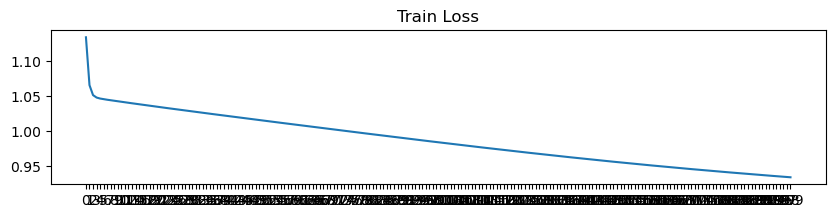

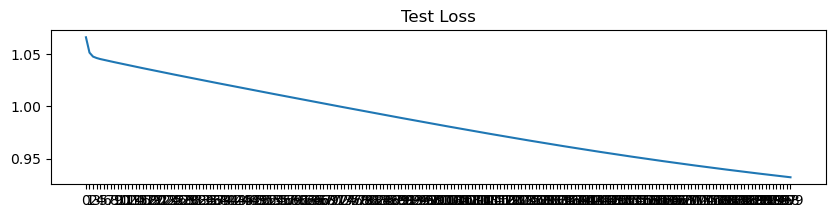

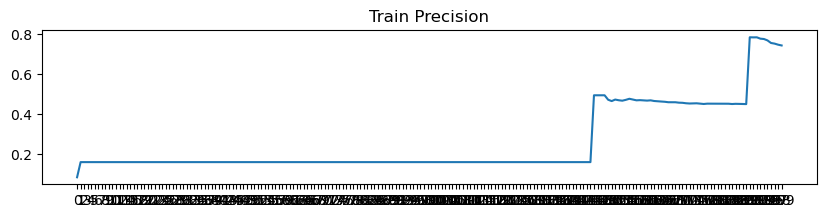

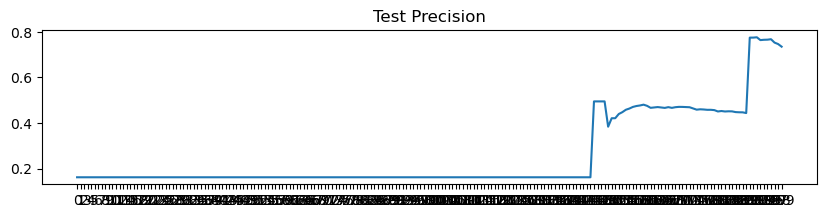

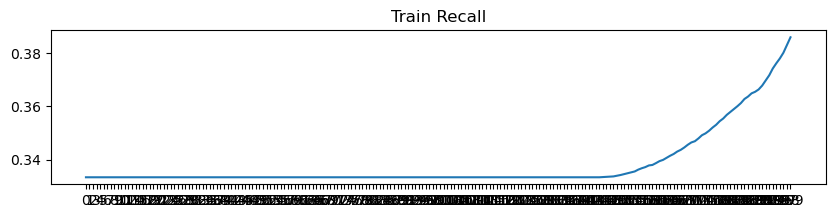

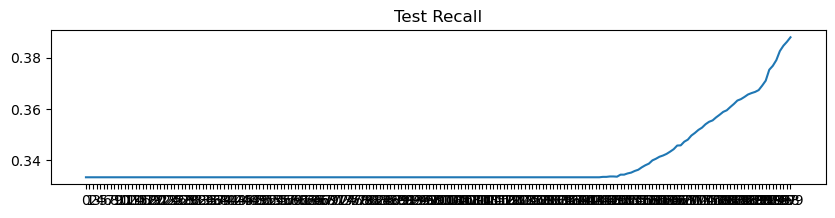

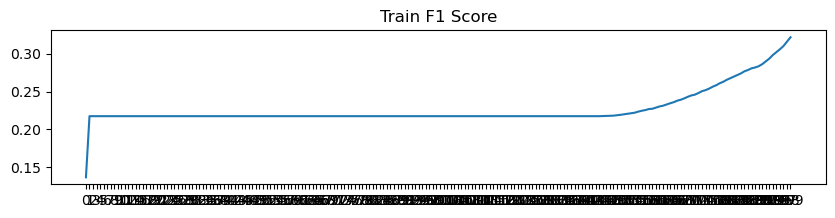

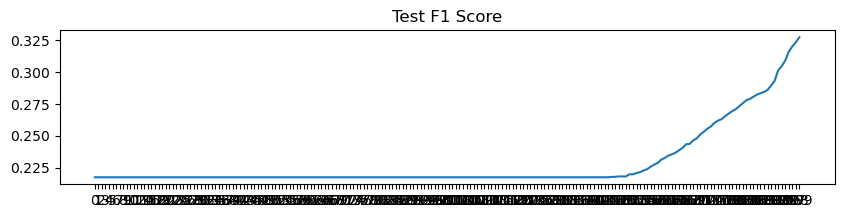

In [346]:
plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[0]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[0])
plt.show()

plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[1]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[1])
plt.show()

plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[2]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[2])
plt.show()


plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[3]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[3])
plt.show()

plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[4]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[4])
plt.show()

plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[5]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[5])
plt.show()

plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[6]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[6])
plt.show()


plt.figure(figsize=(10,2))
plt.plot(epochs, tensor_metrics[tensor_metrics_keys[7]])
plt.xticks(epochs)
plt.title(tensor_metrics_keys[7])
plt.show()


In [347]:
logits=model(X_test)
predict_probs=nn.Softmax(dim=1)(logits)
y_pred=predict_probs.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([2, 2, 2,  ..., 2, 2, 2])


In [348]:
con_matrix(y_pred,y_test,).sum(axis=1) 

tensor([1., 1., 1.])

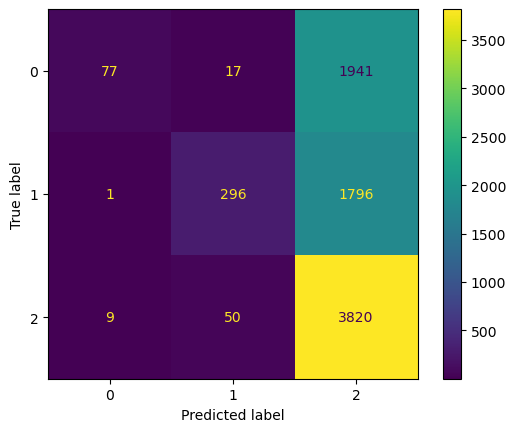

In [349]:
y_pred_np = y_pred.cpu().numpy()
y_true_np = y_test.cpu().numpy()
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_matrix = confusion_matrix(y_true_np, y_pred_np)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot()
plt.show()

In [328]:
results=pd.DataFrame(tensor_metrics)
results['Loss Function']="CrossEntropyLoss()"
results['Optimizer']="torch.optim.SGD(model.parameters(),lr=0.83)"
results['Activation']="Sigmoid"

In [330]:
# data={'Sheet1':results}

data.update({'Sheet4':results})

In [331]:
data.keys()

dict_keys(['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4'])

In [1131]:
# with pd.ExcelWriter('output1.xlsx') as writer:
#     for sheet_name, data in data.items():
#         data.to_excel(writer, sheet_name=sheet_name, index=False)